# Cohort Retention Analysis

This notebook builds monthly cohort retention tables from cleaned transaction data.


In [1]:
import os
import sys
from pathlib import Path

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start, *start.parents]:
        if (p / "src").is_dir():
            return p
    raise FileNotFoundError("Could not find project root containing a 'src' folder.")

project_root = find_project_root(Path.cwd())

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

os.chdir(project_root)

print("cwd:", Path.cwd())
print("project_root:", project_root)
print("src exists:", (project_root / "src").exists())
print("src in sys.path:", str(project_root) in sys.path)

cwd: C:\Users\Aarush\OneDrive\Desktop\customer_segmentation_starter\customer-segmentation-starter
project_root: C:\Users\Aarush\OneDrive\Desktop\customer_segmentation_starter\customer-segmentation-starter
src exists: True
src in sys.path: True


In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.cohort import build_cohort_retention

sns.set_theme(style="whitegrid")

In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.cohort import build_cohort_retention
sns.set_theme(style='whitegrid')


In [4]:
from pathlib import Path

clean_path = Path('data/processed/online_retail_clean.csv')
if not clean_path.exists():
    raise FileNotFoundError(f'File not found: {clean_path.resolve()}')

df = pd.read_csv(clean_path, parse_dates=['InvoiceDate'])
retention = build_cohort_retention(df)
retention.head()


CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12-01,1.0,0.366102,0.323164,0.384181,0.362712,0.397740,0.362712,0.349153,0.353672,0.395480,0.374011,0.502825,0.265537
2011-01-01,1.0,0.220624,0.266187,0.230216,0.321343,0.287770,0.247002,0.242206,0.299760,0.326139,0.364508,0.117506,NaN
2011-02-01,1.0,0.186842,0.186842,0.284211,0.271053,0.247368,0.252632,0.278947,0.247368,0.305263,0.068421,NaN,NaN
2011-03-01,1.0,0.150442,0.252212,0.199115,0.223451,0.168142,0.267699,0.230088,0.278761,0.086283,NaN,NaN,NaN
2011-04-01,1.0,0.213333,0.203333,0.210000,0.196667,0.226667,0.216667,0.260000,0.073333,NaN,NaN,NaN,NaN


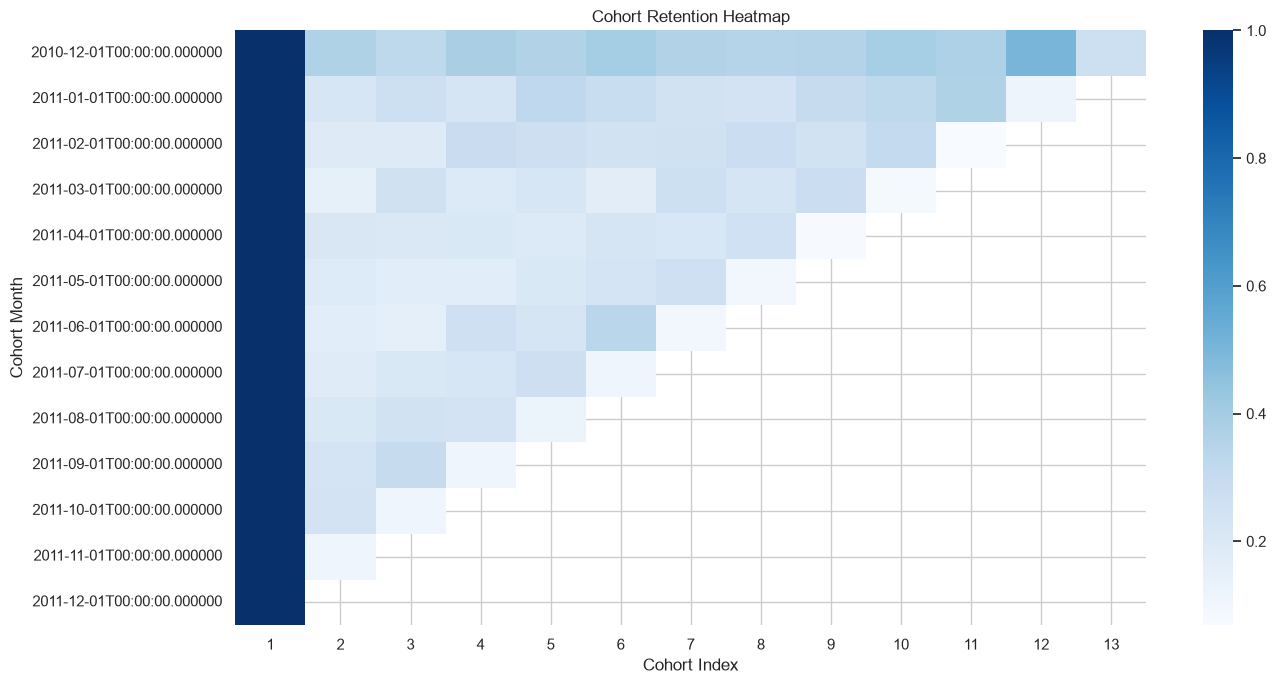

In [5]:
plt.figure(figsize=(14, 7))
sns.heatmap(retention, cmap='Blues', annot=False)
plt.title('Cohort Retention Heatmap')
plt.xlabel('Cohort Index')
plt.ylabel('Cohort Month')
plt.tight_layout()


In [6]:
retention.iloc[:, :6].round(3)


CohortIndex,1,2,3,4,5,6
CohortMonth,,,,,,
2010-12-01,1.0,0.366,0.323,0.384,0.363,0.398
2011-01-01,1.0,0.221,0.266,0.230,0.321,0.288
2011-02-01,1.0,0.187,0.187,0.284,0.271,0.247
2011-03-01,1.0,0.150,0.252,0.199,0.223,0.168
2011-04-01,1.0,0.213,0.203,0.210,0.197,0.227
2011-05-01,1.0,0.190,0.173,0.173,0.208,0.232
2011-06-01,1.0,0.174,0.157,0.264,0.231,0.335
2011-07-01,1.0,0.181,0.207,0.223,0.271,0.112
2011-08-01,1.0,0.207,0.249,0.243,0.124,NaN


## Interpretation

Use this heatmap to explain whether later acquisition cohorts retain better or worse than earlier ones.
